# Drei Messreihen - Drei Verteilungen

Drei Experimente wurden durchgeführt, zu denen jeweils eine Messreihe mit repräsentativen Werten vorliegt.

Im ersten Experiment wurde die Beschleunigung eines Sensors im Ruhezustand gemessen. 

Im zweiten Experiment wurde der Ausschlagwinkel eines ballistischen Pendels mit einem digitalen Winkelencoder mit einer Auflösung von 0,5 Grad erfasst. 

Das dritte Experiment kombiniert die Signale von zwei digitalen Sensoren mit gleicher Auflösung. 

In allen drei Fällen sollen die jeweiligen Messwerte statistisch ausgewertet werden. Dazu sind für jede Messreihe der Mittelwert, die Standardabweichung sowie die Standard- und erweiterte Messunsicherheit zu bestimmen.
Anschließend sind die resultierenden Wahrscheinlichkeitsverteilungen grafisch darzustellen, der Mittelwert und die Grenzen der ±1σ-Streuung im Diagramm zu markieren und die Ergebnisse physikalisch zu interpretieren.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, triang


## Darstellung

Lesen Sie die Messdaten ein und erstellen Sie für alle drei Datensätze Histogramme der Messwerte um die zugrundeliegende Verteilung zu visualisieren.

In [66]:
# --------------------------------------------
# 1. Messdaten einladen
# --------------------------------------------
# CSV-Dateien laden
data_normal = np.loadtxt("beschleunigungsmessung.csv", delimiter=",")
data_rect   = np.loadtxt("pendelausschlag.csv", delimiter=",")
data_tri    = np.loadtxt("zweiDigitalsensoren.csv", delimiter=",")

print("Datensätze wurden eingelesen.\n")

Datensätze wurden eingelesen.



Alternativ können Sie sich auch direkt in Python die Messdaten generieren:

In [67]:
# --------------------------------------------
# 1. Datengenerierung
# --------------------------------------------
np.random.seed(42)  # für reproduzierbare Ergebnisse

# (A) 
data_normal = np.random.normal(loc=0.0, scale=0.02, size=1200)

# (B) 
delta = 0.5  # Auflösung des Encoders
true_angle = 12.3
data_rect = true_angle + (np.random.rand(1200) - 0.5) * delta

# (C) 
u1 = (np.random.rand(1200) - 0.5) * delta
u2 = (np.random.rand(1200) - 0.5) * delta
data_tri = true_angle + (u1 + u2)

# Speicherung der Datensätze (optional)
np.savetxt("beschleunigungsmessung.csv", data_normal, delimiter=",")
np.savetxt("pendelausschlag.csv", data_rect, delimiter=",")
np.savetxt("zweiDigitalsensoren.csv", data_tri, delimiter=",")

print("Datensätze wurden erzeugt und gespeichert.\n")

Datensätze wurden erzeugt und gespeichert.



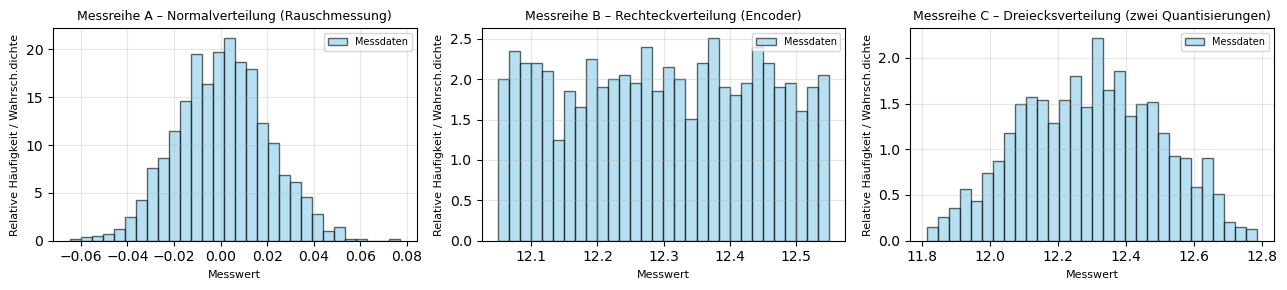

In [68]:
# --------------------------------------------------------------
# 2. Visualisierung
# --------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=False)

datasets = [
    (data_normal, "Messreihe A – Normalverteilung (Rauschmessung)"),
    (data_rect,   "Messreihe B – Rechteckverteilung (Encoder)"),
    (data_tri,    "Messreihe C – Dreiecksverteilung (zwei Quantisierungen)")
]

for ax, (data, title) in zip(axes, datasets):
    # Histogramm plotten
    counts, bins, _ = ax.hist(
        data,
        bins=30,
        density=True,
        color="skyblue",
        edgecolor="black",
        alpha=0.6,
        label="Messdaten"
    )
    
    # Achsenbeschriftungen und Titel
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Messwert", fontsize=8)
    ax.set_ylabel("Relative Häufigkeit / Wahrsch.dichte", fontsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

# Gesamtlayout optimieren
plt.tight_layout()
plt.show()

Sollten Sie sich unsicher sein, welche Verteilung vorliegt, kann man in Python schnell mittels Shapiro–Wilk-Tests überprüfen, ob eine Stichprobe normalverteilt ist.
Er testet ausschließlich auf Normalverteilung und wird häufig als Standardverfahren zur Beurteilung der Verteilungsannahme verwendet.
Die Nullhypothese $H_0$ lautet dabei, dass die vorliegenden Daten normalverteilt sind.

Als Entscheidungsregel gilt:
Liegt der berechnete p-Wert unter 0,05, wird die Nullhypothese verworfen.
Dies bedeutet, dass die Daten signifikant von einer Normalverteilung abweichen.

Wird der Test nicht bestanden, ist es wahrscheinlich, dass die Daten einer anderen Verteilungsform, beispielsweise einer Dreiecksverteilung oder einer anderen nicht-normalen Verteilung, folgen.

In [69]:
from scipy.stats import shapiro

print('---- Messreihe 1 --------------------------------')
stat, p = shapiro(data_normal)
print(f"Shapiro–Wilk-Test: Statistik={stat:.4f}, p={p:.4f}")
if p > 0.05:
    print("→ Daten sind vereinbar mit Normalverteilung.\n")
else:
    print("→ Daten weichen signifikant von Normalverteilung ab.\n")


print('---- Messreihe 2 --------------------------------')
stat, p = shapiro(data_rect)
print(f"Shapiro–Wilk-Test: Statistik={stat:.4f}, p={p:.4f}")
if p > 0.05:
    print("→ Daten sind vereinbar mit Normalverteilung.\n")
else:
    print("→ Daten weichen signifikant von Normalverteilung ab.\n")

print('---- Messreihe 3 --------------------------------')
stat, p = shapiro(data_tri)
print(f"Shapiro–Wilk-Test: Statistik={stat:.4f}, p={p:.4f}")
if p > 0.05:
    print("→ Daten sind vereinbar mit Normalverteilung.\n")
else:
    print("→ Daten weichen signifikant von Normalverteilung ab.\n")

---- Messreihe 1 --------------------------------
Shapiro–Wilk-Test: Statistik=0.9992, p=0.8946
→ Daten sind vereinbar mit Normalverteilung.

---- Messreihe 2 --------------------------------
Shapiro–Wilk-Test: Statistik=0.9555, p=0.0000
→ Daten weichen signifikant von Normalverteilung ab.

---- Messreihe 3 --------------------------------
Shapiro–Wilk-Test: Statistik=0.9913, p=0.0000
→ Daten weichen signifikant von Normalverteilung ab.



Neben dem Shapiro–Wilk-Test, der ausschließlich auf Normalverteilung prüft, existieren auch weitere statistische Verfahren, mit denen Daten auf andere Verteilungsformen getestet werden können.
Für die vorliegende Aufgabenstellung ist es jedoch ausreichend, zwischen einer Normalverteilung und einer Dreiecksverteilung sicher unterscheiden zu können, da diese beiden Verteilungen die charakteristischen Grenzfälle der betrachteten Messsituationen darstellen.

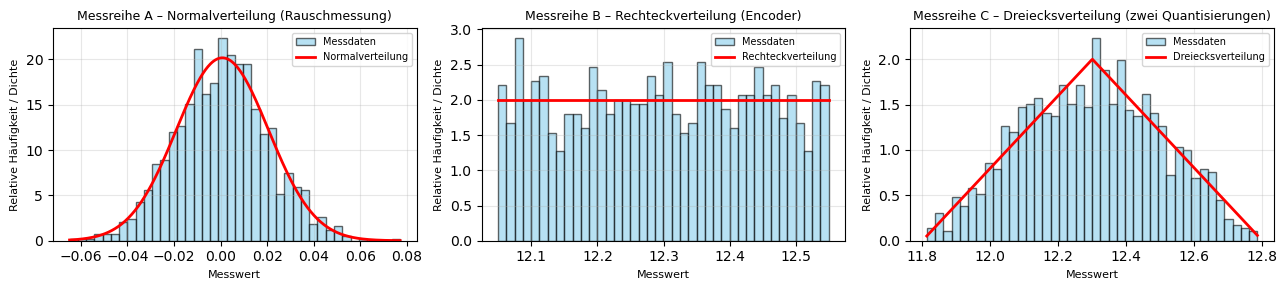

In [70]:
# --------------------------------------------------------------
# 2. Visualisierung mit Theorie
# --------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=False)

for ax, (data, title) in zip(axes, datasets):
    # Histogramm der Messdaten
    counts, bins, _ = ax.hist(
        data,
        bins=40,
        density=True,
        color="skyblue",
        edgecolor="black",
        alpha=0.6,
        label="Messdaten"
    )
    
    # x-Achse für theoretische Dichte
    x = np.linspace(min(data), max(data), 400)
    
    # Theoretische Verteilungen
    if "Normal" in title:
        pdf = norm.pdf(x, loc=np.mean(data), scale=np.std(data, ddof=1))
        ax.plot(x, pdf, "r-", lw=2, label="Normalverteilung")
    
    elif "Rechteck" in title:
        a = true_angle - delta/2
        b = true_angle + delta/2
        pdf = uniform.pdf(x, loc=a, scale=(b - a))
        ax.plot(x, pdf, "r-", lw=2, label="Rechteckverteilung")
    
    elif "Dreiecks" in title:
        a = true_angle - delta
        b = true_angle + delta
        c = 0.5  # Symmetrische Dreiecksverteilung
        pdf = triang.pdf((x - a) / (b - a), c) / (b - a)
        ax.plot(x, pdf, "r-", lw=2, label="Dreiecksverteilung")
    
    # Layout & Beschriftung
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Messwert", fontsize=8)
    ax.set_ylabel("Relative Häufigkeit / Dichte", fontsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

# Gesamtlayout anpassen
plt.tight_layout()
plt.show()

## Diskussion der Verteilungen 

Sind die zu beobachtenden Verteilungen plausibel für die jeweiligen Experimente? Ja:

Im 1. Experiment registriert der Beschleunigungs-Sensor im Ruhezustand kleine zufällige Schwankungen um den Wert null, die durch elektronisches Rauschen und Umwelteinflüsse entstehen. Solche Messwerte folgen typischerweise einer Normalverteilung, da viele kleine, unabhängige Störeinflüsse additiv wirken.

Im 2. Experiment können die Messwerte für die Winkelauslesung aufgrund der begrenzten Auflösung des Encoders (0,5°) nur in diskreten Schritten dargestellt werden. Die Werte innerhalb des möglichen Intervalls sind gleich wahrscheinlich, sodass eine Rechteckverteilung entsteht.

Im 3. Experiment werden die Quantisierungsfehler (Rechteckverteilung, da auch hier eine begrenzte Auflösung vorliegt) von zwei Sensoren überlagert woraus sich eine Dreiecksverteilung ergibt: Messwerte in der Nähe des Mittelwertes treten häufiger auf, während die Wahrscheinlichkeit zu den Randwerten hin linear abnimmt.


## Statistische Auswertung

Bei der statistischen Auswertung der Stichproben werden – unabhängig von der zugrunde liegenden Verteilung – der Mittelwert und die Standardabweichung berechnet.

In [71]:
# --------------------------------------------
# 3. Statistische Auswertung
# --------------------------------------------
def summary_stats(data, label):
    """Berechnet Mittelwert, Standardabweichung und Unsicherheit."""
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    print(f"{label}")
    print(f"  Mittelwert        = {mean:.5f}")
    print(f"  Standardabweichung = {std:.5f}")
    return mean, std

meanA, sA = summary_stats(data_normal, "Messreihe A – Normalverteilung")
meanB, sB = summary_stats(data_rect,   "Messreihe B – Rechteckverteilung")
meanC, sC = summary_stats(data_tri,    "Messreihe C – Dreiecksverteilung")

print("\n")

Messreihe A – Normalverteilung
  Mittelwert        = 0.00077
  Standardabweichung = 0.01977
Messreihe B – Rechteckverteilung
  Mittelwert        = 12.29867
  Standardabweichung = 0.14428
Messreihe C – Dreiecksverteilung
  Mittelwert        = 12.29506
  Standardabweichung = 0.20265




Der Mittelwert beschreibt die zentrale Lage der Messwerte und gibt an, um welchen Wert sich die Beobachtungen im Mittel gruppieren.
Die Standardabweichung quantifiziert die Streuung der Messwerte um diesen Mittelwert.

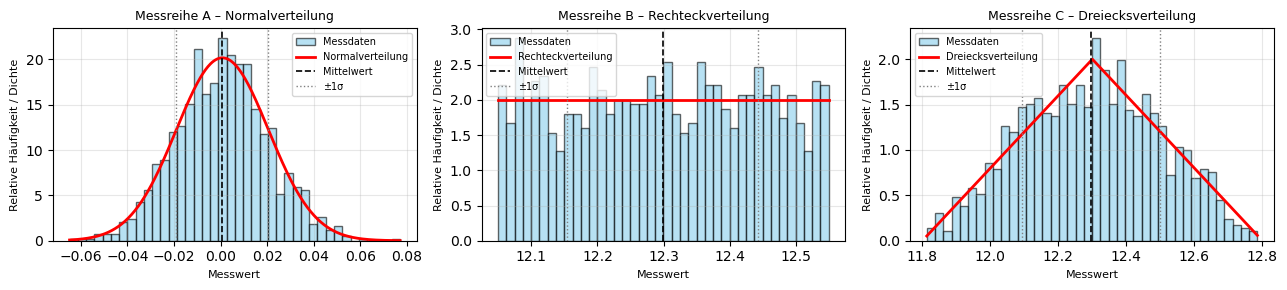

In [72]:
# --------------------------------------------------------------
# 2. Visualisierung mit Theorie, Mittelwert und Standardabweichung
# --------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=False)

# Mittelwerte und Standardabweichungen aus der Statistik
stats = [
    (data_normal, meanA, sA, "Messreihe A – Normalverteilung"),
    (data_rect,   meanB, sB, "Messreihe B – Rechteckverteilung"),
    (data_tri,    meanC, sC, "Messreihe C – Dreiecksverteilung")
]

for ax, (data, mean, std, title) in zip(axes, stats):
    # Histogramm der Messdaten
    counts, bins, _ = ax.hist(
        data,
        bins=40,
        density=True,
        color="skyblue",
        edgecolor="black",
        alpha=0.6,
        label="Messdaten"
    )
    
    # x-Achse für theoretische Dichte
    x = np.linspace(min(data), max(data), 400)
    
    # Theoretische Verteilungen
    if "Normal" in title:
        pdf = norm.pdf(x, loc=mean, scale=std)
        ax.plot(x, pdf, "r-", lw=2, label="Normalverteilung")
    
    elif "Rechteck" in title:
        a = true_angle - delta/2
        b = true_angle + delta/2
        pdf = uniform.pdf(x, loc=a, scale=(b - a))
        ax.plot(x, pdf, "r-", lw=2, label="Rechteckverteilung")
    
    elif "Dreiecks" in title:
        a = true_angle - delta
        b = true_angle + delta
        c = 0.5  # Symmetrische Dreiecksverteilung
        pdf = triang.pdf((x - a) / (b - a), c) / (b - a)
        ax.plot(x, pdf, "r-", lw=2, label="Dreiecksverteilung")
    
    # Linien für Mittelwert und ±1 Standardabweichung
    ax.axvline(mean, color="k", linestyle="--", lw=1.2, label="Mittelwert")
    ax.axvline(mean - std, color="gray", linestyle=":", lw=1, label="±1σ")
    ax.axvline(mean + std, color="gray", linestyle=":", lw=1)
    
    # Layout & Beschriftung
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Messwert", fontsize=8)
    ax.set_ylabel("Relative Häufigkeit / Dichte", fontsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

# Gesamtlayout anpassen
plt.tight_layout()
plt.show()

## Berechnung der Messunsicherheit des Mittelwertes

Aus der Streuung der Einzelmesswerte lässt sich die **Messunsicherheit des Mittelwertes** ableiten.  
Während die Standardabweichung $s$ die Schwankung der einzelnen Messwerte um den Mittelwert beschreibt, gibt die **Standardunsicherheit des Mittelwertes** $u_{\bar{x}}$ an, mit welcher Genauigkeit der Mittelwert selbst bestimmt ist.  

Da der Mittelwert mit wachsender Anzahl an Messungen stabiler wird, verringert sich seine Unsicherheit mit der Wurzel aus der Stichprobengröße $n$:  

$$
u(\bar{x}) = \frac{s}{\sqrt{n}}
$$

Hierbei gilt:
- $s$ – empirische Standardabweichung der Stichprobe  
- $n$ – Anzahl der unabhängigen Messwerte  

Die Unsicherheit des Mittelwertes ist somit ein Maß für die **statistische Präzision** der Schätzung des Erwartungswertes.  
Je größer die Anzahl der Messungen, desto kleiner wird $u_{\bar{x}}$, während die Streuung der Einzelwerte (Standardabweichung) selbst davon unabhängig bleibt.  

---

### Verteilungsabhängige Erweiterung (Bewertung der Messunsicherheit)

Für die Berechnung der **Standardunsicherheit einer Einzelmessung** wird die zugrunde liegende Wahrscheinlichkeitsverteilung berücksichtigt.  
Dabei wird der **Verteilungsfaktor $G$** verwendet, der die Form der Verteilung beschreibt:

| Verteilung | Beschreibung | Verteilungsfaktor $G$ |
|-------------|---------------|-----------------------|
| Normalverteilung | zufällige Schwankung um Mittelwert |  $G = 1$ |
| Rechteckverteilung | gleichwahrscheinlicher Fehler im Intervall $\pm a$ | $G = 1/3$ |
| Dreiecksverteilung | lineare Abnahme der Wahrscheinlichkeit von der Mitte zum Rand | $G = 1/6$ |

Der Verteilungsfaktor $G$ wird somit abhängig vom zugrunde liegenden Fehlerverhalten gewählt.

Allgemein gilt zur Berechnung der Messunsicherheit des Mittelwertes also:
$$u = \sqrt{G} \cdot \frac{s}{\sqrt{n}}$$

In [73]:
# --------------------------------------------
# 4. Berechnung der Standardunsicherheiten des Mittelwertes
# --------------------------------------------
u_normal_mean = sA / np.sqrt(len(data_normal))
u_rect_mean = sB / np.sqrt(len(data_rect)) / np.sqrt(3)
u_tri_mean = sC / np.sqrt(len(data_tri)) / np.sqrt(6)

print("Berechnete Standardunsicherheiten für den Mittelwert:")
print(f"  u_normal   = {u_normal_mean:.5f}")
print(f"  u_rechteck = {u_rect_mean:.5f} ")
print(f"  u_dreieck  = {u_tri_mean:.5f} ")

Berechnete Standardunsicherheiten für den Mittelwert:
  u_normal   = 0.00057
  u_rechteck = 0.00240 
  u_dreieck  = 0.00239 


## Angabe der Messergebnisse

Das jeweilige Messergebnis für die drei Messreihen lautet also:

In [74]:
# --------------------------------------------------------------
# 6. Ausgabe der Messergebnisse
# --------------------------------------------------------------

print("## Messergebnisse der drei Experimente\n")

# Experiment A – Normalverteilung
print("Experiment A – Normalverteilung (Sensorrauschen)")
print(f"x̄ = {meanA:.5f} ± {u_normal_mean:.5f}  [Einheit]\n")

# Experiment B – Rechteckverteilung
print("Experiment B – Rechteckverteilung (Encoder)")
print(f"x̄ = {meanB:.5f} ± {u_rect_mean:.5f}  [Einheit]\n")

# Experiment C – Dreiecksverteilung
print("Experiment C – Dreiecksverteilung (zwei Quantisierungen)")
print(f"x̄ = {meanC:.5f} ± {u_tri_mean:.5f}  [Einheit]\n")

print("Hinweis: Die angegebenen Unsicherheiten entsprechen den Standardunsicherheiten (1σ-Niveau).")

## Messergebnisse der drei Experimente

Experiment A – Normalverteilung (Sensorrauschen)
x̄ = 0.00077 ± 0.00057  [Einheit]

Experiment B – Rechteckverteilung (Encoder)
x̄ = 12.29867 ± 0.00240  [Einheit]

Experiment C – Dreiecksverteilung (zwei Quantisierungen)
x̄ = 12.29506 ± 0.00239  [Einheit]

Hinweis: Die angegebenen Unsicherheiten entsprechen den Standardunsicherheiten (1σ-Niveau).
